# Adversarial Training on CIFAR-10
## Standard vs PGD-$L_\infty$ vs PGD-$L_2$

In this notebook, we train and evaluate three models with the same ResNet
architecture:

1. Standard training
2. PGD-$L_\infty$ adversarial training
3. PGD-$L_2$ adversarial training

Finally, we evaluate all three models against both $L_\infty$ and $L_2$
PGD attacks to study cross-norm robustness.

In [1]:
RUN_ON_COLAB = False

COLAB_PROJECT_ROOT = "/content/drive/MyDrive/FGSM_PGD"

In [2]:
import sys
from pathlib import Path

if RUN_ON_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    PROJECT_ROOT = Path(COLAB_PROJECT_ROOT)

else:
    PROJECT_ROOT = Path.cwd()

    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/ali/Desktop/LAB/practical/pgd_robustness_across_norms


In [3]:
DATA_PATH = PROJECT_ROOT / "data"
CHECKPOINTS_PATH = PROJECT_ROOT / "checkpoints"
RESULTS_PATH = PROJECT_ROOT / "results"

DATA_PATH.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

In [4]:
import torch
import random 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from src.data.cifar10 import (
    create_cifar10_datasets,
    create_cifar10_loaders,
)
from src.models.resnet import create_cifar10_resnet20
from src.attacks.pgd import (
    pgd_linf,
    pgd_l2,
)
import torch.optim as optim

from src.training.engine import (
    train_one_epoch,
    train_one_epoch_adversarial,
    evaluate_clean,
    evaluate_adversarial,
)

## 1. Reproducibility

All three models will use the same:

- dataset split,
- architecture,
- optimizer family,
- training duration,
- data augmentation,
- random seed configuration.

The main difference between the three experiments will be the training input:

$$
\text{Standard: } x
$$

$$
L_\infty\text{-training: } x_{\text{adv}}^{(\infty)}
$$

$$
L_2\text{-training: } x_{\text{adv}}^{(2)}
$$

In [5]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [6]:
SEED = 42
set_seed(SEED)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

## 2. CIFAR-10 Data Pipeline

Adversarial perturbations will be generated directly in pixel space:

$$
x \in [0,1].
$$

Therefore, the CIFAR-10 dataset will **not** be normalized inside the dataset
transform.

This keeps perturbation budgets interpretable. For example,

$$
\epsilon = \frac{8}{255}
$$

means that each pixel component may change by at most $8/255$ under an
$L_\infty$ constraint.

Normalization will later be applied inside the model pipeline.

In [8]:
NUM_CLASSES = 10

BATCH_SIZE = 128
NUM_WORKERS = 2

NUM_EPOCHS = 40
NUM_EPOCHS_ADVERSARIAL = 40

LEARNING_RATE = 0.1
WEIGHT_DECAY = 5e-4
MOMENTUM = 0.9

In [9]:
VAL_SIZE = 5000

In [10]:
train_dataset, val_dataset, test_dataset = (
    create_cifar10_datasets(
        root=DATA_PATH,
        val_size=VAL_SIZE,
        seed=SEED,
        download=True,
    )
)

print(f"Train samples:      {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

Train samples:      45000
Validation samples: 5000
Test samples:       10000


In [11]:
train_loader, val_loader, test_loader = (
    create_cifar10_loaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        seed=SEED,
    )
)

In [12]:
# Sanity Check

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Pixel min:", images.min().item())
print("Pixel max:", images.max().item())

Images shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Pixel min: 0.0
Pixel max: 1.0


In [13]:
# Sanity Check

model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)

model


CIFAR10ResNet20(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05,

In [14]:
# Sanity Check

num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(model.conv1)
print("Layer 1 blocks:", len(model.layer1))
print("Layer 2 blocks:", len(model.layer2))
print("Layer 3 blocks:", len(model.layer3))
print(f"Total parameters: {num_parameters:,}")

with torch.no_grad():
    dummy_logits = model(
        torch.rand(4, 3, 32, 32, device=device)
    )

print("Output shape:", dummy_logits.shape)


Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Layer 1 blocks: 3
Layer 2 blocks: 3
Layer 3 blocks: 3
Total parameters: 269,722
Output shape: torch.Size([4, 10])


## 3. PGD Attacks

A PGD attack repeatedly performs four operations:

1. Compute the gradient of the loss with respect to the input.
2. Take a norm-specific ascent step.
3. Project the perturbation back into the allowed norm ball.
4. Clamp the resulting image to the valid pixel range $[0,1]$.

A random initialization inside the perturbation ball is used before the
iterations begin.

For $L_\infty$:

$$
d_t = \alpha\,\mathrm{sign}(\nabla_x L)
$$

For $L_2$:

$$
d_t =
\alpha
\frac{\nabla_xL}
{\|\nabla_xL\|_2}.
$$

In [15]:
# PGD-Linf training
LINF_EPSILON = 8 / 255
LINF_STEP_SIZE = 2 / 255
LINF_STEPS = 7

# PGD-L2 training
L2_EPSILON = 0.5
L2_STEP_SIZE = 0.1
L2_STEPS = 7

RANDOM_START = True

## 4. Standard Training

The standard model is trained only on clean CIFAR-10 examples:

$$
\min_\theta L(\theta,x,y).
$$

This model provides the baseline for our later robustness experiments.

All three models will use the same:

- ResNet-20 architecture,
- optimizer,
- learning-rate schedule,
- number of epochs,
- data augmentation.

The only major difference will be whether the training inputs are clean or
generated by a PGD adversary.

In [16]:
standard_train_loader, _, _ = create_cifar10_loaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    seed=SEED,
)

In [17]:
set_seed(SEED)

standard_model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)

standard_optimizer = torch.optim.SGD(
    standard_model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

standard_scheduler = torch.optim.lr_scheduler.MultiStepLR(
    standard_optimizer,
    milestones=[30, 36],
    gamma=0.1,
)

In [18]:
standard_checkpoint_path = CHECKPOINTS_PATH / "resnet20_cifar10_standard_best.pt"

In [19]:
standard_history = []

best_val_accuracy = -float("inf")
best_epoch = None


for epoch in range(1, NUM_EPOCHS + 1):

    train_metrics = train_one_epoch(
        model=standard_model,
        loader=standard_train_loader,
        optimizer=standard_optimizer,
        device=device,
    )

    val_metrics = evaluate_clean(
        model=standard_model,
        loader=val_loader,
        device=device,
    )

    current_lr = (
        standard_optimizer
        .param_groups[0]["lr"]
    )

    is_best = (
        val_metrics["accuracy"]
        > best_val_accuracy
    )

    if is_best:

        best_val_accuracy = val_metrics["accuracy"]
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    standard_model.state_dict(),

                "optimizer_state_dict":
                    standard_optimizer.state_dict(),

                "scheduler_state_dict":
                    standard_scheduler.state_dict(),

                "val_accuracy":
                    val_metrics["accuracy"],

                "val_loss":
                    val_metrics["loss"],

                "training_type":
                    "standard",

                "seed":
                    SEED,
            },
            standard_checkpoint_path,
        )

    standard_history.append({
        "epoch": epoch,
        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "lr":
            current_lr,

        "best":
            is_best,
    })

    standard_scheduler.step()

    marker = " *" if is_best else ""

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {100 * train_metrics['accuracy']:.2f}% | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {100 * val_metrics['accuracy']:.2f}% | "
        f"LR: {current_lr:.5f}"
        f"{marker}"
    )

Epoch 001/40 | Train Loss: 1.6916 | Train Acc: 36.39% | Val Loss: 1.5380 | Val Acc: 45.72% | LR: 0.10000 *
Epoch 002/40 | Train Loss: 1.2297 | Train Acc: 55.61% | Val Loss: 1.2667 | Val Acc: 55.10% | LR: 0.10000 *
Epoch 003/40 | Train Loss: 0.9798 | Train Acc: 65.23% | Val Loss: 1.0302 | Val Acc: 64.14% | LR: 0.10000 *
Epoch 004/40 | Train Loss: 0.8223 | Train Acc: 71.12% | Val Loss: 0.9062 | Val Acc: 68.58% | LR: 0.10000 *
Epoch 005/40 | Train Loss: 0.7319 | Train Acc: 74.84% | Val Loss: 0.9012 | Val Acc: 70.02% | LR: 0.10000 *
Epoch 006/40 | Train Loss: 0.6787 | Train Acc: 76.66% | Val Loss: 0.9242 | Val Acc: 71.54% | LR: 0.10000 *
Epoch 007/40 | Train Loss: 0.6443 | Train Acc: 77.74% | Val Loss: 0.6989 | Val Acc: 76.42% | LR: 0.10000 *
Epoch 008/40 | Train Loss: 0.6168 | Train Acc: 78.63% | Val Loss: 0.8678 | Val Acc: 71.30% | LR: 0.10000
Epoch 009/40 | Train Loss: 0.6036 | Train Acc: 79.18% | Val Loss: 0.8360 | Val Acc: 73.84% | LR: 0.10000
Epoch 010/40 | Train Loss: 0.5810 | Train

In [20]:
print(f"Best epoch: {best_epoch}")
print(
    f"Best validation accuracy: "
    f"{100 * best_val_accuracy:.2f}%"
)

Best epoch: 40
Best validation accuracy: 90.38%


In [21]:
standard_history_df = pd.DataFrame(
    standard_history
)

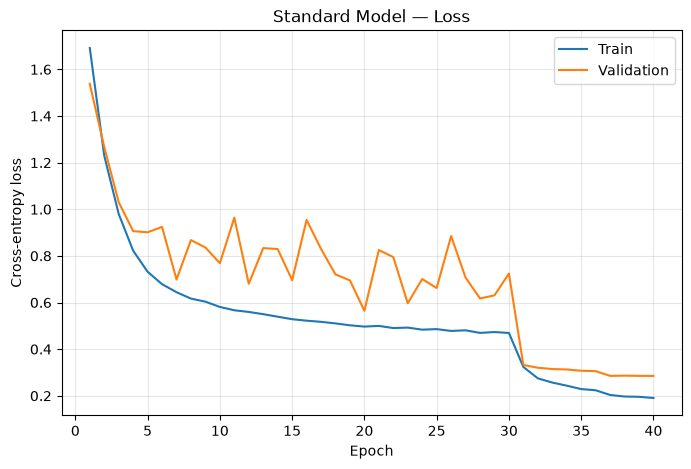

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    standard_history_df["epoch"],
    standard_history_df["train_loss"],
    label="Train",
)

ax.plot(
    standard_history_df["epoch"],
    standard_history_df["val_loss"],
    label="Validation",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Standard Model — Loss")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

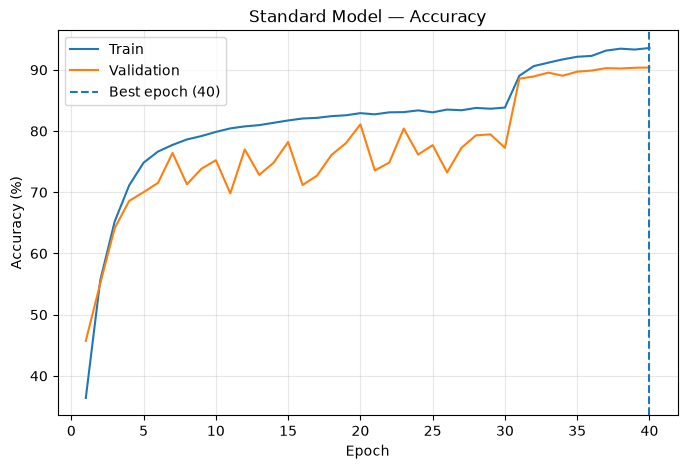

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    standard_history_df["epoch"],
    100 * standard_history_df["train_accuracy"],
    label="Train",
)

ax.plot(
    standard_history_df["epoch"],
    100 * standard_history_df["val_accuracy"],
    label="Validation",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch ({best_epoch})",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Standard Model — Accuracy")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

In [24]:
best_standard_checkpoint = torch.load(
    standard_checkpoint_path,
    map_location=device,
)

standard_model.load_state_dict(
    best_standard_checkpoint[
        "model_state_dict"
    ]
)

print(
    "Loaded best standard checkpoint "
    f"from epoch "
    f"{best_standard_checkpoint['epoch']}."
)

Loaded best standard checkpoint from epoch 40.


In [25]:
standard_test_metrics = evaluate_clean(
    model=standard_model,
    loader=test_loader,
    device=device,
)

print(
    f"Clean test accuracy: "
    f"{100 * standard_test_metrics['accuracy']:.2f}%"
)

print(
    f"Clean test loss: "
    f"{standard_test_metrics['loss']:.4f}"
)

Clean test accuracy: 89.91%
Clean test loss: 0.2993


## 5. PGD-$L_\infty$ Adversarial Training

In adversarial training, each clean training batch is first perturbed by an adversary and the model is then optimized on the resulting adversarial examples.

For PGD-$L_\infty$ training, we solve:

$$
\min_\theta
L(\theta, x_{\mathrm{adv}}^{(\infty)}, y),
$$

where

$$
\|x_{\mathrm{adv}}^{(\infty)} - x\|_\infty \leq \epsilon.
$$

In [26]:
linf_train_loader, _, _ = create_cifar10_loaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    seed=SEED,
)

In [27]:
set_seed(SEED)

linf_model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)


linf_optimizer = torch.optim.SGD(
    linf_model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)


linf_scheduler = torch.optim.lr_scheduler.MultiStepLR(
    linf_optimizer,
    milestones=[30, 36],
    gamma=0.1,
)

In [28]:
linf_attack_kwargs = {
    "epsilon": LINF_EPSILON,
    "step_size": LINF_STEP_SIZE,
    "steps": LINF_STEPS,
    "random_start": RANDOM_START,
}

In [29]:
linf_checkpoint_path = CHECKPOINTS_PATH / "resnet20_cifar10_pgd_linf_best.pt"

In [30]:
linf_history = []

best_linf_val_accuracy = -float("inf")
best_linf_epoch = None


for epoch in range(1, NUM_EPOCHS_ADVERSARIAL + 1):

    train_metrics = train_one_epoch_adversarial(
        model=linf_model,
        loader=linf_train_loader,
        optimizer=linf_optimizer,
        device=device,
        attack_fn=pgd_linf,
        attack_kwargs=linf_attack_kwargs,
    )

    val_metrics = evaluate_clean(
        model=linf_model,
        loader=val_loader,
        device=device,
    )

    robust_val_metrics = evaluate_adversarial(
        model=linf_model,
        loader=val_loader,
        device=device,
        attack_fn=pgd_linf,
        attack_kwargs=linf_attack_kwargs,
    )

    current_lr = (
        linf_optimizer.param_groups[0]["lr"]
    )
    
    is_best = (
        robust_val_metrics["accuracy"]
        > best_linf_val_accuracy
    )
    
    if is_best:

        best_linf_val_accuracy = robust_val_metrics["accuracy"]
        best_linf_epoch = epoch

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    linf_model.state_dict(),

                "optimizer_state_dict":
                    linf_optimizer.state_dict(),

                "scheduler_state_dict":
                    linf_scheduler.state_dict(),

                "clean_val_accuracy":
                    val_metrics["accuracy"],

                "robust_val_accuracy":
                    robust_val_metrics["accuracy"],

                "val_loss":
                    val_metrics["loss"],

                "training_type":
                    "pgd_linf",

                "epsilon":
                    LINF_EPSILON,

                "step_size":
                    LINF_STEP_SIZE,

                "steps":
                    LINF_STEPS,

                "random_start":
                    RANDOM_START,

                "seed":
                    SEED,
            },
            linf_checkpoint_path,
        )

    linf_history.append({
        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "lr":
            current_lr,

        "best":
            is_best,
    })

    linf_scheduler.step()

    marker = " *" if is_best else ""

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS_ADVERSARIAL} | "
        f"Adv Train Loss: {train_metrics['loss']:.4f} | "
        f"Adv Train Acc: {100 * train_metrics['accuracy']:.2f}% | "
        f"Clean Val Acc: {100 * val_metrics['accuracy']:.2f}% | "
        f"PGD-Linf Val Acc: {100 * robust_val_metrics['accuracy']:.2f}% | "
        f"LR: {current_lr:.5f}"
        f"{marker}"
    )

Epoch 001/40 | Adv Train Loss: 2.1329 | Adv Train Acc: 20.08% | Clean Val Acc: 34.54% | PGD-Linf Val Acc: 24.06% | LR: 0.10000 *
Epoch 002/40 | Adv Train Loss: 1.9896 | Adv Train Acc: 25.46% | Clean Val Acc: 36.56% | PGD-Linf Val Acc: 24.16% | LR: 0.10000 *
Epoch 003/40 | Adv Train Loss: 1.9316 | Adv Train Acc: 27.55% | Clean Val Acc: 43.32% | PGD-Linf Val Acc: 26.94% | LR: 0.10000 *
Epoch 004/40 | Adv Train Loss: 1.8848 | Adv Train Acc: 28.86% | Clean Val Acc: 44.20% | PGD-Linf Val Acc: 29.10% | LR: 0.10000 *
Epoch 005/40 | Adv Train Loss: 1.8425 | Adv Train Acc: 30.61% | Clean Val Acc: 49.22% | PGD-Linf Val Acc: 29.76% | LR: 0.10000 *
Epoch 006/40 | Adv Train Loss: 1.8105 | Adv Train Acc: 31.91% | Clean Val Acc: 46.26% | PGD-Linf Val Acc: 26.80% | LR: 0.10000
Epoch 007/40 | Adv Train Loss: 1.7839 | Adv Train Acc: 32.60% | Clean Val Acc: 51.98% | PGD-Linf Val Acc: 30.62% | LR: 0.10000 *
Epoch 008/40 | Adv Train Loss: 1.7565 | Adv Train Acc: 33.58% | Clean Val Acc: 53.28% | PGD-Linf Va

## 6. PGD-$L_2$ Adversarial Training

The second robust model is trained using PGD adversarial examples constrained by the $L_2$ norm.

For each training batch, PGD generates an adversarial input satisfying

$$
\|x_{\mathrm{adv}}^{(2)} - x\|_2 \leq \epsilon,
$$

and the model is optimized on these perturbed examples.

This allows us to compare how robustness learned under one norm transfers to attacks defined under another norm.


In [37]:
l2_train_loader, _, _ = create_cifar10_loaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    seed=SEED,
)

In [38]:
set_seed(SEED)

l2_model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)


l2_optimizer = torch.optim.SGD(
    l2_model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)


l2_scheduler = torch.optim.lr_scheduler.MultiStepLR(
    l2_optimizer,
    milestones=[30, 36],
    gamma=0.1,
)

In [39]:
l2_attack_kwargs = {
    "epsilon": L2_EPSILON,
    "step_size": L2_STEP_SIZE,
    "steps": L2_STEPS,
    "random_start": RANDOM_START,
}

In [40]:
l2_checkpoint_path = CHECKPOINTS_PATH / "resnet20_cifar10_pgd_l2_best.pt"

In [41]:
l2_history = []

best_l2_val_accuracy = -float("inf")
best_l2_epoch = None


for epoch in range(1, NUM_EPOCHS_ADVERSARIAL + 1):

    train_metrics = train_one_epoch_adversarial(
        model=l2_model,
        loader=l2_train_loader,
        optimizer=l2_optimizer,
        device=device,
        attack_fn=pgd_l2,
        attack_kwargs=l2_attack_kwargs,
    )

    val_metrics = evaluate_clean(
        model=l2_model,
        loader=val_loader,
        device=device,
    )
    
    robust_val_metrics = evaluate_adversarial(
        model=l2_model,
        loader=val_loader,
        device=device,
        attack_fn=pgd_l2,
        attack_kwargs=l2_attack_kwargs,
    )

    current_lr = l2_optimizer.param_groups[0]["lr"]

    is_best = (
        robust_val_metrics["accuracy"]
        > best_l2_val_accuracy
    )
    
    if is_best:

        best_l2_val_accuracy = robust_val_metrics["accuracy"]
        best_l2_epoch = epoch

        torch.save(
            {
                "epoch": 
                    epoch,
                
                "model_state_dict": 
                    l2_model.state_dict(),
                
                "optimizer_state_dict": 
                    l2_optimizer.state_dict(),
                
                "scheduler_state_dict":
                    l2_scheduler.state_dict(),

                "clean_val_accuracy": 
                    val_metrics["accuracy"],
                
                "robust_val_accuracy": 
                    robust_val_metrics["accuracy"],
                
                "val_loss": 
                    val_metrics["loss"],

                "training_type": 
                    "pgd_l2",

                "epsilon": 
                    L2_EPSILON,
                
                "step_size": 
                    L2_STEP_SIZE,
                
                "steps": 
                    L2_STEPS,
                
                "random_start": 
                    RANDOM_START,

                "seed": 
                    SEED,
            },
            l2_checkpoint_path,
        )

    l2_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "lr": current_lr,
        "best": is_best,
    })

    l2_scheduler.step()

    marker = " *" if is_best else ""

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS_ADVERSARIAL} | "
        f"Adv Train Loss: {train_metrics['loss']:.4f} | "
        f"Adv Train Acc: {100 * train_metrics['accuracy']:.2f}% | "
        f"Clean Val Acc: {100 * val_metrics['accuracy']:.2f}% | "
        f"PGD-L2 Val Acc: {100 * robust_val_metrics['accuracy']:.2f}% | "
        f"LR: {current_lr:.5f}"
        f"{marker}"
    )

Epoch 001/40 | Adv Train Loss: 1.9582 | Adv Train Acc: 25.90% | Clean Val Acc: 41.92% | PGD-L2 Val Acc: 34.18% | LR: 0.10000 *
Epoch 002/40 | Adv Train Loss: 1.7305 | Adv Train Acc: 34.74% | Clean Val Acc: 46.64% | PGD-L2 Val Acc: 36.26% | LR: 0.10000 *
Epoch 003/40 | Adv Train Loss: 1.6169 | Adv Train Acc: 39.20% | Clean Val Acc: 49.98% | PGD-L2 Val Acc: 36.74% | LR: 0.10000 *
Epoch 004/40 | Adv Train Loss: 1.5204 | Adv Train Acc: 43.07% | Clean Val Acc: 55.30% | PGD-L2 Val Acc: 41.26% | LR: 0.10000 *
Epoch 005/40 | Adv Train Loss: 1.4452 | Adv Train Acc: 45.41% | Clean Val Acc: 56.22% | PGD-L2 Val Acc: 40.68% | LR: 0.10000
Epoch 006/40 | Adv Train Loss: 1.3936 | Adv Train Acc: 47.97% | Clean Val Acc: 58.04% | PGD-L2 Val Acc: 41.78% | LR: 0.10000 *
Epoch 007/40 | Adv Train Loss: 1.3525 | Adv Train Acc: 49.25% | Clean Val Acc: 56.58% | PGD-L2 Val Acc: 40.32% | LR: 0.10000
Epoch 008/40 | Adv Train Loss: 1.3175 | Adv Train Acc: 50.72% | Clean Val Acc: 64.26% | PGD-L2 Val Acc: 46.24% | LR

## 7. Robustness Evaluation

After training, all three models are evaluated on the same test set under three conditions:

1. Clean images
2. PGD-$L_\infty$ adversarial images
3. PGD-$L_2$ adversarial images

The evaluation attacks use more PGD steps than the training attacks to provide a stronger estimate of model robustness.

In [42]:
EVAL_LINF_EPSILON = 8 / 255
EVAL_LINF_STEP_SIZE = 2 / 255
EVAL_LINF_STEPS = 20

EVAL_L2_EPSILON = 0.5
EVAL_L2_STEP_SIZE = 0.1
EVAL_L2_STEPS = 20

EVAL_RANDOM_START = True

In [43]:
eval_linf_attack_kwargs = {
    "epsilon": EVAL_LINF_EPSILON,
    "step_size": EVAL_LINF_STEP_SIZE,
    "steps": EVAL_LINF_STEPS,
    "random_start": EVAL_RANDOM_START,
}

eval_l2_attack_kwargs = {
    "epsilon": EVAL_L2_EPSILON,
    "step_size": EVAL_L2_STEP_SIZE,
    "steps": EVAL_L2_STEPS,
    "random_start": EVAL_RANDOM_START,
}

In [44]:
standard_checkpoint_path = (
    CHECKPOINTS_PATH
    / "resnet20_cifar10_standard_best.pt"
)

linf_checkpoint_path = (
    CHECKPOINTS_PATH
    / "resnet20_cifar10_pgd_linf_best.pt"
)

l2_checkpoint_path = (
    CHECKPOINTS_PATH
    / "resnet20_cifar10_pgd_l2_best.pt"
)


standard_model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)

linf_model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)

l2_model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)


standard_checkpoint = torch.load(
    standard_checkpoint_path,
    map_location=device,
)

linf_checkpoint = torch.load(
    linf_checkpoint_path,
    map_location=device,
)

l2_checkpoint = torch.load(
    l2_checkpoint_path,
    map_location=device,
)


standard_model.load_state_dict(
    standard_checkpoint["model_state_dict"]
)

linf_model.load_state_dict(
    linf_checkpoint["model_state_dict"]
)

l2_model.load_state_dict(
    l2_checkpoint["model_state_dict"]
)


standard_model.eval()
linf_model.eval()
l2_model.eval()


print(
    "Standard best epoch:",
    standard_checkpoint["epoch"]
)

print(
    "Linf best epoch:",
    linf_checkpoint["epoch"]
)

print(
    "L2 best epoch:",
    l2_checkpoint["epoch"]
)

Standard best epoch: 40
Linf best epoch: 38
L2 best epoch: 39


In [45]:
def evaluate_model_all_attacks(
    model,
    model_name,
):
    clean_metrics = evaluate_clean(
        model=model,
        loader=test_loader,
        device=device,
    )

    set_seed(SEED)

    linf_metrics = evaluate_adversarial(
        model=model,
        loader=test_loader,
        device=device,
        attack_fn=pgd_linf,
        attack_kwargs=eval_linf_attack_kwargs,
    )

    set_seed(SEED)

    l2_metrics = evaluate_adversarial(
        model=model,
        loader=test_loader,
        device=device,
        attack_fn=pgd_l2,
        attack_kwargs=eval_l2_attack_kwargs,
    )

    return {
        "model": model_name,

        "clean_accuracy":
            clean_metrics["accuracy"],

        "pgd_linf_accuracy":
            linf_metrics["accuracy"],

        "pgd_l2_accuracy":
            l2_metrics["accuracy"],
    }

In [46]:
evaluation_results = []

evaluation_results.append(
    evaluate_model_all_attacks(
        model=standard_model,
        model_name="Standard",
    )
)

evaluation_results.append(
    evaluate_model_all_attacks(
        model=linf_model,
        model_name="PGD-Linf Trained",
    )
)

evaluation_results.append(
    evaluate_model_all_attacks(
        model=l2_model,
        model_name="PGD-L2 Trained",
    )
)

In [47]:
results_df = pd.DataFrame(
    evaluation_results
)

results_df[
    [
        "clean_accuracy",
        "pgd_linf_accuracy",
        "pgd_l2_accuracy",
    ]
] *= 100

results_df = results_df.rename(
    columns={
        "model": "Model",
        "clean_accuracy": "Clean Accuracy (%)",
        "pgd_linf_accuracy": "PGD-Linf Accuracy (%)",
        "pgd_l2_accuracy": "PGD-L2 Accuracy (%)",
    }
)

results_df

,Model,Clean Accuracy (%),PGD-Linf Accuracy (%),PGD-L2 Accuracy (%)
0,Standard,89.91,0.00,0.00
1,PGD-Linf Trained,71.94,42.35,54.65
2,PGD-L2 Trained,82.06,24.42,59.27
